In [1]:
import os

In [2]:
CUSTOM_MODEL_NAME = 'my_sdd_mobnet'
PRETRAINED_MODEL_NAME = 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8'
PRETRAINED_MODEL_URL = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz'
TF_RECORD_SCRIPT_NAME = 'generate_tfrecord.py'
LABEL_MAP_NAME = 'label_map.pbtxt'

In [3]:
paths = {
    'PROJECT_PATH': os.path.join('project'),
    'SCRIPT_PATH': os.path.join('scripts'),
    'APIMODEL_PATH': os.path.join('modelsNEW'),
    'ANNOTATION_PATH': os.path.join('project','annotations'),
    'IMAGE_PATH': os.path.join('project','images'),
    'MODEL_PATH': os.path.join('project','modelsNEW'),
    'PRETRAINED_MODEL_PATH': os.path.join('project','pre-trained-models'),
    'CHECKPOINT_PATH': os.path.join('project','modelsNEW',CUSTOM_MODEL_NAME),
    'OUTPUT_PATH': os.path.join('project','modelsNEW',CUSTOM_MODEL_NAME,'export'),
    'TFJS_PATH': os.path.join('project','modelsNEW',CUSTOM_MODEL_NAME,'tfjsexport'),
    'TFLITE_PATH': os.path.join('project','modelsNEW',CUSTOM_MODEL_NAME,'tfliteexport'),
    'PROTOC_PATH': os.path.join('protoc')
}

In [4]:
files = {
    'PIPELINE_CONFIG': os.path.join('project','modelsNEW',CUSTOM_MODEL_NAME,'pipeline.config'),
    'TF_RECORD_SCRIPT': os.path.join(paths['SCRIPT_PATH'],TF_RECORD_SCRIPT_NAME),
    'LABELMAP': os.path.join(paths['ANNOTATION_PATH'], LABEL_MAP_NAME),
    'ASL_LABELMAP': os.path.join(paths['ANNOTATION_PATH'],'label_map.pbtxt')
}

In [5]:
for path in paths.values():
    if not os.path.exists(path):
        if os.name == 'posix':
            !mkdir -p {path}
        if os.name == 'nt':
            !mkdir {path}

In [6]:
if os.name == 'nt':
    import wget

In [7]:
if not os.path.exists(os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection')):
    !git clone https://github.com/tensorflow/models {paths['APIMODEL_PATH']}

In [8]:
if os.name == 'posix':
    !apt-get install protobuf-compiler
    !cd sign-detection/modelsNEW/research && protoc object_detection/protos/*.proto --python_outs=. && cp object_detection/packages/tf2/setup.py . && python -m pip install .
if os.name == 'nt':
    url="https://github.com/protocolbuffers/protobuf/releases/download/v3.19.6/protoc-3.19.6-win64.zip"
    wget.download(url)
    !move protoc-3.19.6-win64.zip {paths['PROTOC_PATH']}
    !cd {paths['PROTOC_PATH']} && tar -xf protoc-3.19.6-win64.zip
    os.environ['PATH'] += os.pathsep + os.path.abspath(os.path.join(paths['PROTOC_PATH'], 'bin'))
    !cd sign-detection/modelsNEW/research && protoc object_detection/protos/*.proto --python_out=. && copy object_detection\\packages\\tf2\\setup.py && python -m pip install . 
    !cd sign-detection/modelsNEW/research/slim && pip install -e .

100% [..........................................................................] 1523222 / 1523222        1 file(s) moved.
        1 file(s) copied.
Processing d:\sign-detection\sign-detection\modelsnew\research
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for object_detection: filename=object_detection-0.1-py3-none-any.whl size=1708899 sha256=c6e73870301b49a6d5a945c7775341a327a20c6075736cf1970fc3d6e607808d
  Stored in directory: C:\Users\karthik\AppData\Local\Temp\pip-ephem-wheel-cache-yk13rp7h\wheels\6a\81\1a\3ea21251011d2c967f3a3ced5a6e94b3193fb24a5918ba6021
Successfully built object_detection
  Attempting uninstall: object_detection
    Found existing installation: object_detection 0.1
    Uninstalling object_detection-0.1:
      Successfully uninstalled object_detection-0.1


  DEPRECATION: Building 'object_detection' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'object_detection'. Discussion can be found at https://github.com/pypa/pip/issues/6334


Obtaining file:///D:/sign-detection/sign-detection/modelsNEW/research/slim
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: slim
    Found existing installation: slim 0.1
    Uninstalling slim-0.1:
      Successfully uninstalled slim-0.1
  Running setup.py develop for slim


  DEPRECATION: Legacy editable install of slim==0.1 from file:///D:/sign-detection/sign-detection/modelsNEW/research/slim (setup.py develop) is deprecated. pip 25.3 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457


In [ ]:
 !cd sign-detection/modelsNEW/research && protoc object_detection/protos/*.proto --python_out=. && copy object_detection\\packages\\tf2\\setup.py && python -m pip install . 
 !cd sign-detection/modelsNEW/research/slim && pip install -e .

In [20]:
VERIFICATION_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'builders', 'model_builder_tf2_test.py')
!python {VERIFICATION_SCRIPT}

Running tests under Python 3.9.23: C:\Users\karthik\.conda\envs\gpuenv\python.exe
[ RUN      ] ModelBuilderTF2Test.test_create_center_net_deepmac
C:\Users\karthik\.conda\envs\gpuenv\lib\site-packages\object_detection\builders\model_builder.py:1112: DeprecationWarning: The 'warn' function is deprecated, use 'warning' instead
  logging.warn(('Building experimental DeepMAC meta-arch.'
W1008 22:59:32.197178 11436 model_builder.py:1112] Building experimental DeepMAC meta-arch. Some features may be omitted.
INFO:tensorflow:time(__main__.ModelBuilderTF2Test.test_create_center_net_deepmac): 2.18s
I1008 22:59:32.741429 11436 test_util.py:2460] time(__main__.ModelBuilderTF2Test.test_create_center_net_deepmac): 2.18s
[       OK ] ModelBuilderTF2Test.test_create_center_net_deepmac
[ RUN      ] ModelBuilderTF2Test.test_create_center_net_model0 (customize_head_params=True)
INFO:tensorflow:time(__main__.ModelBuilderTF2Test.test_create_center_net_model0 (customize_head_params=True)): 4.36s
I1008 22:59

In [7]:
import object_detection

In [22]:
if os.name == 'posix':
    !wget (PRETRAINED_MODEL_URL)
    !mv {PRETRAINED_MODEL_NAME+'.tar.gz'} {paths['PRETRAINED_MODEL_PATH']}
    !cd {paths['PRETRAINED_MODEL_PATH']} && tar -zxvf {PRETRAINED_MODEL_NAME+'.tar.gz'}
if os.name == 'nt':
    wget.download (PRETRAINED_MODEL_URL)
    !move {PRETRAINED_MODEL_NAME+'.tar.gz'} {paths['PRETRAINED_MODEL_PATH']}
    !cd {paths['PRETRAINED_MODEL_PATH']} && tar -zxvf {PRETRAINED_MODEL_NAME+'.tar.gz'}

100% [........................................................................] 20515344 / 20515344        1 file(s) moved.


x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/ckpt-0.data-00000-of-00001
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/checkpoint
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/ckpt-0.index
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model/
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model/saved_model.pb
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model/variables/
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model/variables/variables.data-00000-of-00001
x ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model/variables/variables.index


In [9]:
labels = [{'name':'thumbsup','id': 1},{'name':'thumbsdown','id':2},{'name':'thankyou','id':3},{'name':'livelong','id':4}]

with open(files['LABELMAP'], 'w') as f:
    for label in labels:
        f.write('item {\n')
        f.write('\tname:\'{}\'\n'.format(label['name']))
        f.write('\tid:{}\n'.format(label['id']))
        f.write('}\n')

In [9]:
import tensorflow as tf
import xml.etree.ElementTree as ET
import os
from PIL import Image
import io

def create_label_map(classes):
    """Create label map from class list"""
    return {class_name: idx + 1 for idx, class_name in enumerate(sorted(classes))}

def parse_xml(xml_path):
    """Parse XML annotation file"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Get basic info
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    
    filename_elem = root.find('filename')
    filename = filename_elem.text if filename_elem is not None else os.path.basename(xml_path).replace('.xml', '.jpg')
    
    # Parse all objects
    annotations = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        bbox = obj.find('bndbox')
        
        xmin = int(float(bbox.find('xmin').text))
        ymin = int(float(bbox.find('ymin').text))
        xmax = int(float(bbox.find('xmax').text))
        ymax = int(float(bbox.find('ymax').text))
        
        annotations.append({
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })
    
    return filename, width, height, annotations

def create_tf_example(image_path, xml_path, label_map):
    """Create TensorFlow Example"""
    # Parse XML
    filename, xml_width, xml_height, annotations = parse_xml(xml_path)
    
    # Read image
    with open(image_path, 'rb') as f:
        encoded_jpg = f.read()
    
    # Verify image and get actual dimensions
    img = Image.open(io.BytesIO(encoded_jpg))
    width, height = img.size
    
    # Use actual image dimensions
    if width != xml_width or height != xml_height:
        print(f"Warning: {filename} - XML dims ({xml_width}x{xml_height}) != Image dims ({width}x{height}). Using image dims.")
    
    # Process annotations
    xmins = []
    xmaxs = []
    ymins = []
    ymaxs = []
    classes_text = []
    classes = []
    
    for ann in annotations:
        # Normalize coordinates
        xmins.append(float(ann['xmin']) / width)
        xmaxs.append(float(ann['xmax']) / width)
        ymins.append(float(ann['ymin']) / height)
        ymaxs.append(float(ann['ymax']) / height)
        
        classes_text.append(ann['class'].encode('utf8'))
        classes.append(label_map[ann['class']])
    
    # Create TF Example
    tf_example = tf.train.Example(features=tf.train.Features(feature={
        'image/height': tf.train.Feature(int64_list=tf.train.Int64List(value=[height])),
        'image/width': tf.train.Feature(int64_list=tf.train.Int64List(value=[width])),
        'image/filename': tf.train.Feature(bytes_list=tf.train.BytesList(value=[filename.encode('utf8')])),
        'image/source_id': tf.train.Feature(bytes_list=tf.train.BytesList(value=[filename.encode('utf8')])),
        'image/encoded': tf.train.Feature(bytes_list=tf.train.BytesList(value=[encoded_jpg])),
        'image/format': tf.train.Feature(bytes_list=tf.train.BytesList(value=[b'jpg'])),
        'image/object/bbox/xmin': tf.train.Feature(float_list=tf.train.FloatList(value=xmins)),
        'image/object/bbox/xmax': tf.train.Feature(float_list=tf.train.FloatList(value=xmaxs)),
        'image/object/bbox/ymin': tf.train.Feature(float_list=tf.train.FloatList(value=ymins)),
        'image/object/bbox/ymax': tf.train.Feature(float_list=tf.train.FloatList(value=ymaxs)),
        'image/object/class/text': tf.train.Feature(bytes_list=tf.train.BytesList(value=classes_text)),
        'image/object/class/label': tf.train.Feature(int64_list=tf.train.Int64List(value=classes)),
    }))
    
    return tf_example

def generate_tfrecord(image_dir, output_path):
    """Generate TFRecord file from images and XML annotations"""
    
    print("="*70)
    print("TFRecord Generation")
    print("="*70)
    
    # Get all XML files
    xml_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.xml')])
    print(f"\nFound {len(xml_files)} XML annotation files")
    
    # Scan for all classes
    print("\nScanning for classes...")
    all_classes = set()
    for xml_file in xml_files:
        xml_path = os.path.join(image_dir, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall('object'):
            all_classes.add(obj.find('name').text)
    
    # Create label map
    label_map = create_label_map(all_classes)
    print(f"\nDetected {len(label_map)} classes:")
    for class_name, label_id in sorted(label_map.items(), key=lambda x: x[1]):
        print(f"  {label_id}: {class_name}")
    
    # Generate TFRecord
    print(f"\nGenerating TFRecord: {output_path}")
    print("-"*70)
    
    writer = tf.io.TFRecordWriter(output_path)
    
    success_count = 0
    error_count = 0
    errors = []
    
    for i, xml_file in enumerate(xml_files):
        # Progress update
        if (i + 1) % 100 == 0:
            print(f"Progress: {i + 1}/{len(xml_files)} ({success_count} successful, {error_count} errors)")
        
        try:
            xml_path = os.path.join(image_dir, xml_file)
            image_file = xml_file.replace('.xml', '.jpg')
            image_path = os.path.join(image_dir, image_file)
            
            # Check if image exists
            if not os.path.exists(image_path):
                raise FileNotFoundError(f"Image not found: {image_file}")
            
            # Create TF Example
            tf_example = create_tf_example(image_path, xml_path, label_map)
            
            # Write to TFRecord
            writer.write(tf_example.SerializeToString())
            success_count += 1
            
        except Exception as e:
            error_count += 1
            error_msg = f"{xml_file}: {str(e)}"
            errors.append(error_msg)
            if error_count <= 10:  # Print first 10 errors
                print(f"ERROR: {error_msg}")
    
    writer.close()
    
    # Final report
    print("\n" + "="*70)
    print("GENERATION COMPLETE")
    print("="*70)
    print(f"\nSuccessfully processed: {success_count}/{len(xml_files)}")
    print(f"Errors: {error_count}/{len(xml_files)}")
    print(f"\nOutput file: {output_path}")
    
    if os.path.exists(output_path):
        file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
        print(f"File size: {file_size_mb:.2f} MB")
        
        # Verify
        print("\nVerifying TFRecord...")
        record_count = sum(1 for _ in tf.data.TFRecordDataset(output_path))
        print(f"TFRecord contains: {record_count} examples")
        
        if record_count == success_count:
            print("✓ Verification successful!")
        else:
            print(f"⚠ Warning: Expected {success_count} but found {record_count}")
    
    print("="*70)
    
    # Save label map
    label_map_path = output_path.replace('.tfrecord', '_label_map.txt')
    with open(label_map_path, 'w') as f:
        for class_name, label_id in sorted(label_map.items(), key=lambda x: x[1]):
            f.write(f"{label_id}: {class_name}\n")
    print(f"\nLabel map saved to: {label_map_path}")
    
    return success_count, error_count

# Run generation
if __name__ == "__main__":
    image_dir = "D:/sign-detection-small/project/images/ASL_TRAIN"
    output_path = "D:/sign-detection-small/project/annotations/asl_train.tfrecord"
    
    generate_tfrecord(image_dir, output_path)

TFRecord Generation

Found 747 XML annotation files

Scanning for classes...

Detected 29 classes:
  1: A
  2: B
  3: C
  4: D
  5: Delete
  6: E
  7: F
  8: G
  9: H
  10: I
  11: J
  12: K
  13: L
  14: M
  15: N
  16: Nothing
  17: O
  18: P
  19: Q
  20: R
  21: S
  22: Space
  23: T
  24: U
  25: V
  26: W
  27: X
  28: Y
  29: Z

Generating TFRecord: D:/sign-detection-small/project/annotations/asl_train.tfrecord
----------------------------------------------------------------------


AttributeError: module 'tensorflow' has no attribute 'io'

In [9]:
if not os.path.exists(files['TF_RECORD_SCRIPT']):
    !git clone https://github.com/nicknochnack/GenerateTFRecord {paths['SCRIPT_PATH']}

Cloning into 'scripts'...


In [29]:
#!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'],'ASL_TRAIN')} -l {files['ASL_LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'ASL.train.record')}
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'],'ASL.TEST')} -l {files['ASL_LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'ASL.test.record')}

Successfully created the TFRecord file: project\annotations\ASL.test.record


In [10]:
if os.name == 'posix':
    !cp {os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'pipeline.config')} {os.path.join(paths['CHECKPOINT_PATH'])}
if os.name == 'nt':
    !copy {os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'pipeline.config')} {os.path.join(paths['CHECKPOINT_PATH'])}

        1 file(s) copied.


In [12]:
!pip install tensorflow-compat

ERROR: Could not find a version that satisfies the requirement tensorflow-compat (from versions: none)
ERROR: No matching distribution found for tensorflow-compat


In [8]:
import tensorflow as tf
from object_detection.utils import config_util
from object_detection.protos import pipeline_pb2
from google.protobuf import text_format

In [9]:
config = config_util.get_configs_from_pipeline_file(files['PIPELINE_CONFIG'])

In [9]:
config

{'model': ssd {
   num_classes: 29
   image_resizer {
     fixed_shape_resizer {
       height: 320
       width: 320
     }
   }
   feature_extractor {
     type: "ssd_mobilenet_v2_fpn_keras"
     depth_multiplier: 1.0
     min_depth: 16
     conv_hyperparams {
       regularizer {
         l2_regularizer {
           weight: 3.9999998989515007e-05
         }
       }
       initializer {
         random_normal_initializer {
           mean: 0.0
           stddev: 0.009999999776482582
         }
       }
       activation: RELU_6
       batch_norm {
         decay: 0.996999979019165
         scale: true
         epsilon: 0.0010000000474974513
       }
     }
     use_depthwise: true
     override_base_feature_extractor_hyperparams: true
     fpn {
       min_level: 3
       max_level: 7
       additional_layer_depth: 128
     }
   }
   box_coder {
     faster_rcnn_box_coder {
       y_scale: 10.0
       x_scale: 10.0
       height_scale: 5.0
       width_scale: 5.0
     }
   }
   matc

In [30]:
pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], "r") as f:
    proto_str = f.read()
    text_format.Merge(proto_str, pipeline_config)

In [40]:
"""pipeline_config.model.ssd.num_classes = 29
pipeline_config.train_config.batch_size = 8
pipeline_config.train_config.fine_tune_checkpoint = os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'checkpoint', 'ckpt-0')
pipeline_config.train_config.fine_tune_checkpoint_type = "detection"
pipeline_config.train_input_reader.label_map_path= files['ASL_LABELMAP']
pipeline_config.train_input_reader.tf_record_input_reader.input_path[:] = [os.path.join(paths['ANNOTATION_PATH'], 'ASL.train.record')]
pipeline_config.eval_input_reader[0].label_map_path = files['ASL_LABELMAP']
pipeline_config.eval_input_reader[0].tf_record_input_reader.input_path[:] = [os.path.join(paths['ANNOTATION_PATH'], 'ASL.test.record')]

In [41]:
config_text = text_format.MessageToString(pipeline_config)                                                                                                                                                                                                        
#with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], "wb") as f:                                                                                                                                                                                                                     
    f.write(config_text)  

In [42]:
TRAINING_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'model_main_tf2.py')

In [45]:
command = "python {} --model_dir={} --pipeline_config_path={} --num_train_steps=40000".format(TRAINING_SCRIPT, paths['CHECKPOINT_PATH'],files['PIPELINE_CONFIG'])

In [46]:
print(command)

python modelsNEW\research\object_detection\model_main_tf2.py --model_dir=project\modelsNEW\my_sdd_mobnet --pipeline_config_path=project\modelsNEW\my_sdd_mobnet\pipeline.config --num_train_steps=40000


In [29]:
command = "python {} --model_dir={} --pipeline_config_path={} --checkpoint_dir={}".format(TRAINING_SCRIPT, paths['CHECKPOINT_PATH'],files['PIPELINE_CONFIG'], paths['CHECKPOINT_PATH'])


In [30]:
print(command)

python modelsNEW\research\object_detection\model_main_tf2.py --model_dir=project\modelsNEW\my_sdd_mobnet --pipeline_config_path=project\modelsNEW\my_sdd_mobnet\pipeline.config --checkpoint_dir=project\modelsNEW\my_sdd_mobnet


In [10]:
import cv2
import tensorflow as tf
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.builders import model_builder
from object_detection.utils import config_util

import numpy as np

from matplotlib import pyplot as plt
%matplotlib inline



In [9]:
!pip list

Package                       Version        Editable project location
----------------------------- -------------- --------------------------------------------------------
absl-py                       1.4.0
anyio                         4.9.0
apache-beam                   2.46.0
argon2-cffi                   25.1.0
argon2-cffi-bindings          21.2.0
array-record                  0.4.1
arrow                         1.3.0
asttokens                     3.0.0
astunparse                    1.6.3
async-lru                     2.0.5
attrs                         25.3.0
avro-python3                  1.10.2
babel                         2.17.0
beautifulsoup4                4.13.4
bleach                        6.2.0
cachetools                    5.5.2
certifi                       2025.7.14
cffi                          1.17.1
charset-normalizer            3.4.2
chex                          0.1.90
click                         8.1.8
cloudpickle                   2.2.1
colorama              

In [11]:
# Load pipeline config and build a detection model
configs = config_util.get_configs_from_pipeline_file(files['PIPELINE_CONFIG'])
detection_model = model_builder.build(model_config=configs['model'], is_training=False)

In [12]:
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)
ckpt.restore(os.path.join(paths['CHECKPOINT_PATH'], 'ckpt-41')).expect_partial()

In [13]:
@tf.function
def detect_fn(image):
    image, shapes = detection_model.preprocess(image)
    prediction_dict = detection_model.predict(image, shapes)
    detections = detection_model.postprocess(prediction_dict, shapes)
    return detections

In [14]:
category_index = label_map_util.create_category_index_from_labelmap(files['ASL_LABELMAP'])

In [15]:
IMAGE_PATH = os.path.join(paths['IMAGE_PATH'], 'ASL_TRAIN', 'A1.jpg')

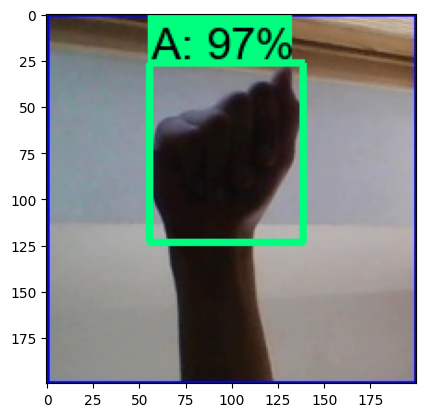

In [16]:
img = cv2.imread(IMAGE_PATH)
image_np = np.array(img)

input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.float32)
detections = detect_fn(input_tensor)

num_detections = int(detections.pop('num_detections'))
detections = {key: value[0, :num_detections].numpy()
              for key, value in detections.items()}
detections['num_detections'] = num_detections

# detection_classes should be ints.
detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

label_id_offset = 1
image_np_with_detections = image_np.copy()

viz_utils.visualize_boxes_and_labels_on_image_array(
            image_np_with_detections,
            detections['detection_boxes'],
            detections['detection_classes']+label_id_offset,
            detections['detection_scores'],
            category_index,
            use_normalized_coordinates=True,
            max_boxes_to_draw=5,
            min_score_thresh=.8,
            agnostic_mode=False)

plt.imshow(cv2.cvtColor(image_np_with_detections, cv2.COLOR_BGR2RGB))
plt.show()

In [108]:
import cv2
import time

In [17]:
cap = cv2.VideoCapture(0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

while cap.isOpened(): 
    ret, frame = cap.read()
    
    image_np = np.array(frame)
    
    input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype = tf.float32)
    detections = detect_fn(input_tensor)
    
    num_detections = int(detections.pop('num_detections'))
    detections = {key: value[0, :num_detections].numpy()
                  for key, value in detections.items()}
    detections['num_detections'] = num_detections

    # detection_classes should be ints.
    detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

    label_id_offset = 1
    image_np_with_detections = image_np.copy()

    viz_utils.visualize_boxes_and_labels_on_image_array(
                image_np_with_detections,
                detections['detection_boxes'],
                detections['detection_classes']+label_id_offset,
                detections['detection_scores'],
                category_index,
                use_normalized_coordinates=True,
                max_boxes_to_draw=5,
                min_score_thresh=.8,
                agnostic_mode=False)

    cv2.imshow('object detection',  cv2.resize(image_np_with_detections, (800, 600)))
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        cap.release()
        cv2.destroyAllWindows()
        break

In [18]:
FREEZE_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'exporter_main_v2.py ')

In [19]:
command = "python {} --input_type=image_tensor --pipeline_config_path={} --trained_checkpoint_dir={} --output_directory={}".format(FREEZE_SCRIPT ,files['PIPELINE_CONFIG'], paths['CHECKPOINT_PATH'], paths['OUTPUT_PATH'])

In [20]:
print(command)

python modelsNEW\research\object_detection\exporter_main_v2.py  --input_type=image_tensor --pipeline_config_path=project\modelsNEW\my_sdd_mobnet\pipeline.config --trained_checkpoint_dir=project\modelsNEW\my_sdd_mobnet --output_directory=project\modelsNEW\my_sdd_mobnet\export


In [21]:
!{command}

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.map_fn(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.map_fn(fn, elems))
W1115 11:38:26.897126 21316 deprecation.py:623] From C:\Users\karthik\.conda\envs\gpuenv\lib\site-packages\tensorflow\python\autograph\impl\api.py:458: calling map_fn_v2 (from tensorflow.python.ops.map_fn) with back_prop=False is deprecated and will be removed in a future version.
Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.map_fn(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.map_fn(fn, elems))
I1115 11:38:36.231550 21316 api.py:459] feature_map_spatial_dims: [(40, 40), (20, 20), (10, 10), (5, 5), (3, 3)]
I1115 11:39:05.742205 21316 api.py:459] feature_map_spatial_dims: [(40, 40), (20, 20), (10, 10), (5, 5), (3, 3)]
I1115 11:39:25.09765

In [25]:
!pip install tensorflowjs

  Using cached tensorflow-2.20.0-cp39-cp39-win_amd64.whl.metadata (4.6 kB)
     ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
     - -------------------------------------- 0.5/15.2 MB 1.5 MB/s eta 0:00:10
     -- ------------------------------------- 0.8/15.2 MB 1.4 MB/s eta 0:00:11
     -- ------------------------------------- 0.8/15.2 MB 1.4 MB/s eta 0:00:11
     -- ------------------------------------- 1.0/15.2 MB 1.3 MB/s eta 0:00:11
     ---- ----------------------------------- 1.6/15.2 MB 1.5 MB/s eta 0:00:10
     ----- ---------------------------------- 2.1/15.2 MB 1.6 MB/s eta 0:00:09
     ------ --------------------------------- 2.4/15.2 MB 1.6 MB/s eta 0:00:09
     ------- -------------------------------- 2.9/15.2 MB 1.6 MB/s eta 0:00:08
     ------- -------------------------------- 2.9/15.2 MB 1.6 MB/s eta 0:00:08
     -------- ------------------------------- 3.1/15.2 MB 1.5 MB/s eta

  DEPRECATION: Building 'tensorflow-decision-forests' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'tensorflow-decision-forests'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\karthik\\.conda\\envs\\gpuenv\\Lib\\site-packages\\tensorflow\\compiler\\tf2tensorrt\\_pywrap_py_utils.pyd'
Consider using the `--user` option or check the permissions.



   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ---------------------  6/13 [tensorboard]
   ------------------ ------------------

In [22]:
command = "tensorflowjs_converter --input_format=tf_saved_model --output_node_names='detection_boxes,detection_classes,detection_features,detection_multiclass_scores,detection_scores,num_detections,raw_detection_boxes,raw_detection_scores' --output_format=tfjs_graph_model --signature_name=serving_default {} {}".format(os.path.join(paths['OUTPUT_PATH'], 'saved_model'), paths['TFJS_PATH'])

In [23]:
print(command)

tensorflowjs_converter --input_format=tf_saved_model --output_node_names='detection_boxes,detection_classes,detection_features,detection_multiclass_scores,detection_scores,num_detections,raw_detection_boxes,raw_detection_scores' --output_format=tfjs_graph_model --signature_name=serving_default project\modelsNEW\my_sdd_mobnet\export\saved_model project\modelsNEW\my_sdd_mobnet\tfjsexport


In [24]:
!{command}

'tensorflowjs_converter' is not recognized as an internal or external command,
operable program or batch file.


In [40]:
TFLITE_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'export_tflite_graph_tf2.py ')
command = "python {} --pipeline_config_path={} --trained_checkpoint_dir={} --output_directory={}".format(TFLITE_SCRIPT ,files['PIPELINE_CONFIG'], paths['CHECKPOINT_PATH'], paths['TFLITE_PATH'])
print(command)

python sign-detection\modelsNEW\research\object_detection\export_tflite_graph_tf2.py  --pipeline_config_path=sign-detection\project\modelsNEW\my_sdd_mobnet\pipeline.config --trained_checkpoint_dir=sign-detection\project\modelsNEW\my_sdd_mobnet --output_directory=sign-detection\project\modelsNEW\my_sdd_mobnet\tfliteexport


In [ ]:
!{command}

In [ ]:
FROZEN_TFLITE_PATH = os.path.join(paths['TFLITE_PATH'], 'saved_model')
TFLITE_MODEL = os.path.join(paths['TFLITE_PATH'], 'saved_model', 'detect.tflite')
command = "tflite_convert \
--saved_model_dir={} \
--output_file={} \
--input_shapes=1,300,300,3 \
--input_arrays=normalized_input_image_tensor \
--output_arrays='TFLite_Detection_PostProcess','TFLite_Detection_PostProcess:1','TFLite_Detection_PostProcess:2','TFLite_Detection_PostProcess:3' \
--inference_type=FLOAT \
--allow_custom_ops".format(FROZEN_TFLITE_PATH, TFLITE_MODEL, )
print(command)

In [ ]:
!{command}

In [ ]:
!tar -czf models.tar.gz {paths['CHECKPOINT_PATH']}
from google.colab import drive
drive.mount('/content/drive')